In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    # Historical 95% VaR
    var95 = np.percentile(returns, 5)

    # Historical CVaR
    cvar95 = returns[returns <= var95].mean()

    results.append({
        "amfi_code": code,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_df = pd.DataFrame(results)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
funds = pd.read_csv("../data/processed/01_fund_master_clean.csv")

var_df = var_df.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

var_df.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [8]:
var_df = var_df.sort_values("VaR_95")

var_df.head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


In [9]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [10]:
import numpy as np

nav["rolling_mean"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).mean())
)

nav["rolling_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).std())
)

nav["rolling_sharpe"] = (
    (nav["rolling_mean"] / nav["rolling_std"]) * np.sqrt(252)
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [11]:
top5 = nav["amfi_code"].drop_duplicates().head(5)

top5

0       100016
1150    100025
2300    100033
3450    101206
4600    101207
Name: amfi_code, dtype: int64

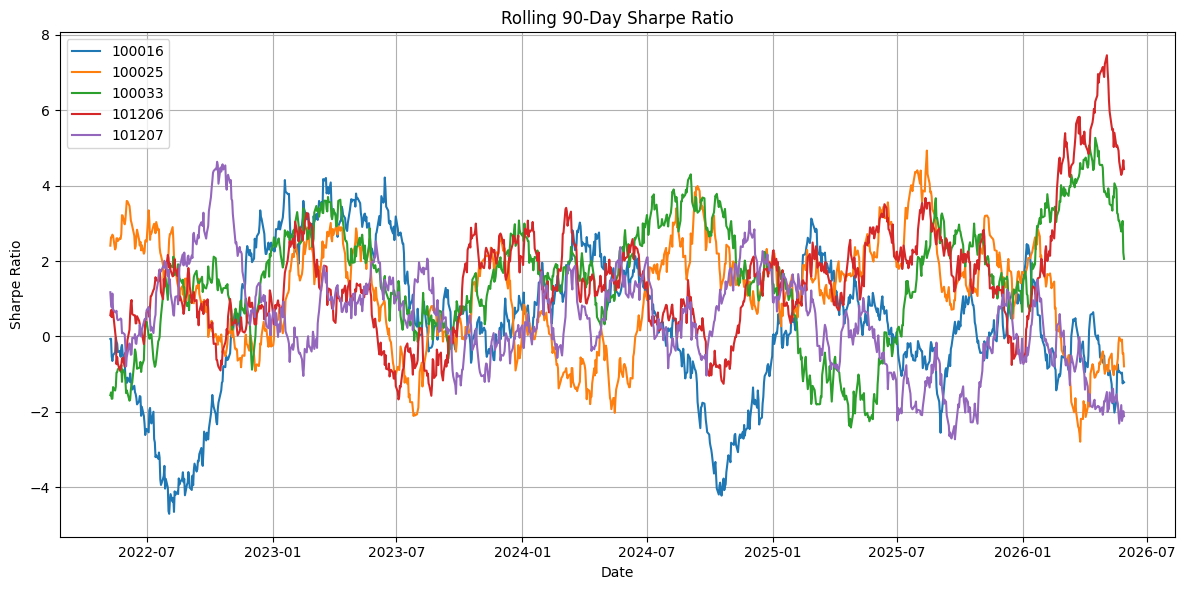

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for code in top5:

    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

In [13]:
plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

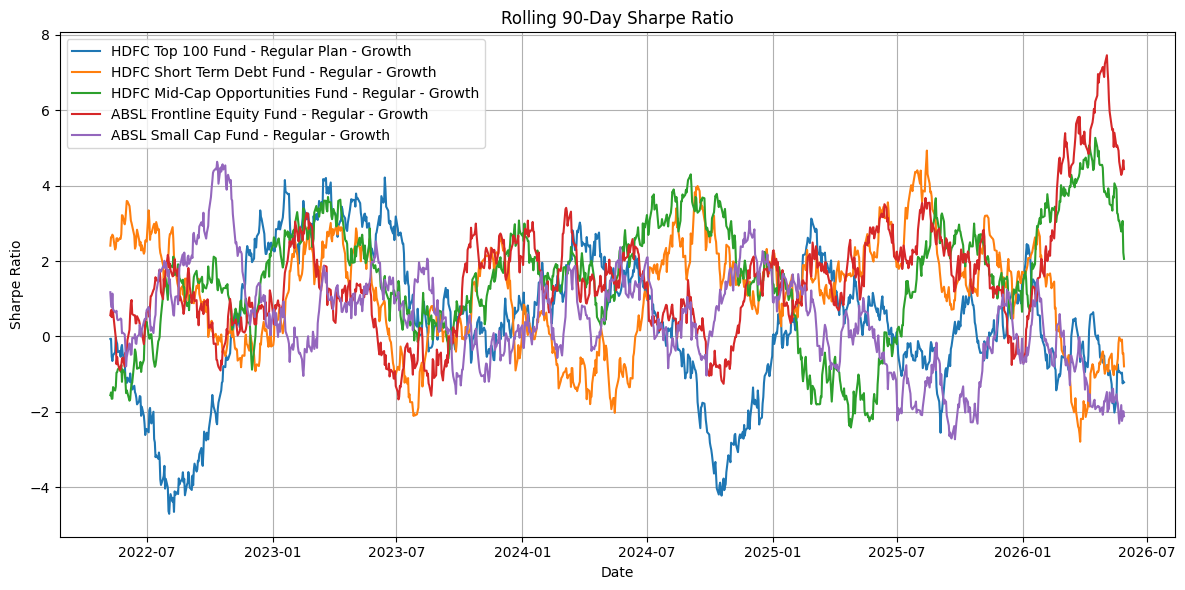

In [14]:
fund_lookup = funds.set_index("amfi_code")["scheme_name"].to_dict()

plt.figure(figsize=(12,6))

for code in top5:

    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["rolling_sharpe"],
        label=fund_lookup.get(code, str(code))
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

In [15]:
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [16]:
first_year = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_year.columns = ["investor_id", "cohort_year"]

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [17]:
transactions = transactions.merge(
    first_year,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [18]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        avg_sip_amount=("transaction_amount", "mean"),
        total_invested=("transaction_amount", "sum")
    )
    .reset_index()
)

cohort_summary

KeyError: "Column(s) ['transaction_amount'] do not exist"

In [19]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']


In [20]:
cohort_summary = (
    transactions.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum")
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [21]:
funds = pd.read_csv("../data/processed/01_fund_master_clean.csv")

funds.head()


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [22]:
transactions = transactions.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024,Mirae Asset Large Cap Fund - Regular - Growth
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024,Axis Midcap Fund - Regular - Growth


In [23]:
top_funds = (
    transactions.groupby(["cohort_year", "scheme_name"])
    .size()
    .reset_index(name="count")
)

top_funds = (
    top_funds.sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

top_funds

,cohort_year,scheme_name,count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
57,2025,ICICI Pru Liquid Fund - Regular - Growth,12


In [24]:
top_funds = top_funds[
    ["cohort_year", "scheme_name"]
]

top_funds.columns = [
    "cohort_year",
    "top_fund"
]

top_funds

,cohort_year,top_fund
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...
57,2025,ICICI Pru Liquid Fund - Regular - Growth


In [25]:
cohort_summary = cohort_summary.merge(
    top_funds,
    on="cohort_year",
    how="left"
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,top_fund
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,ICICI Pru Liquid Fund - Regular - Growth


In [26]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("cohort_analysis.csv saved successfully!")

cohort_analysis.csv saved successfully!


In [27]:
sip = transactions[
    transactions["transaction_type"].str.upper() == "SIP"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024,Axis Bluechip Fund - Regular - Growth
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024,Nippon India Gilt Securities Fund - Regular - ...
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024,Nippon India Small Cap Fund - Regular - Growth
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024,ABSL Liquid Fund - Regular - Growth


In [28]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip_counts = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

sip = sip[
    sip["investor_id"].isin(eligible)
]

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name
4773,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth
6418,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth
8271,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth
12003,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth
28749,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,DSP Small Cap Fund - Regular - Growth


In [29]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,scheme_name,gap_days
4773,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,ABSL Liquid Fund - Regular - Growth,NaN
6418,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,Axis Small Cap Fund - Regular - Growth,26.0
8271,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,Kotak Liquid Fund - Regular - Growth,28.0
12003,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,Mirae Asset Tax Saver Fund - Regular - Growth,59.0
28749,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,DSP Small Cap Fund - Regular - Growth,265.0


In [30]:
sip_gap = (
    sip.groupby("investor_id")
       .agg(
           avg_gap_days=("gap_days", "mean"),
           sip_transactions=("gap_days", "count")
       )
       .reset_index()
)

sip_gap.head()

,investor_id,avg_gap_days,sip_transactions
0,INV000004,85.400000,5
1,INV000008,70.400000,5
2,INV000010,64.800000,5
3,INV000011,40.166667,6
4,INV000012,57.000000,7


In [31]:
sip_gap["status"] = np.where(
    sip_gap["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

sip_gap.head()

,investor_id,avg_gap_days,sip_transactions,status
0,INV000004,85.400000,5,At-Risk
1,INV000008,70.400000,5,At-Risk
2,INV000010,64.800000,5,At-Risk
3,INV000011,40.166667,6,At-Risk
4,INV000012,57.000000,7,At-Risk


In [32]:
sip_gap.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("sip_continuity_report.csv created successfully!")

sip_continuity_report.csv created successfully!


In [33]:
funds.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code']

In [34]:
sharpe = pd.read_csv("../reports/sharpe_ratio.csv")

recommend = funds.merge(
    sharpe,
    on="amfi_code",
    how="left"
)

recommend.head()

,amfi_code,fund_house,scheme_name_x,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,Sharpe_Ratio,scheme_name_y,Sharpe_Rank
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,0.953279,SBI Bluechip Fund - Direct Plan - Growth,12
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,0.945308,SBI Small Cap Fund - Regular Plan - Growth,14
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,-0.057187,SBI Small Cap Fund - Direct Plan - Growth,32
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,-0.226575,SBI Magnum Gilt Fund - Regular Plan - Growth,37


In [35]:
import os
os.listdir("../reports")

['alpha_beta.csv',
 'cagr_comparison.csv',
 'charts',
 'cohort_analysis.csv',
 'data_dictionary.md',
 'fund_scorecard.csv',
 'max_drawdown.csv',
 'sharpe_ratio.csv',
 'sip_continuity_report.csv',
 'sortino_ratio.csv',
 'tracking_error.csv',
 'var_cvar_report.csv']

In [36]:
recommend["risk_category"].unique()

array(['Moderate', 'Very High', 'Low', 'High', 'Moderately High'],
      dtype=object)

In [37]:
sharpe = pd.read_csv("../reports/sharpe_ratio.csv")

sharpe.head()

,amfi_code,Sharpe_Ratio,scheme_name,Sharpe_Rank
0,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1
1,120843,1.306744,Kotak Flexicap Fund - Regular - Growth,2
2,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3
3,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
4,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5


In [38]:
recommend = funds.merge(
    sharpe,
    on="amfi_code",
    how="left"
)

recommend.head()

,amfi_code,fund_house,scheme_name_x,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code,Sharpe_Ratio,scheme_name_y,Sharpe_Rank
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01,0.953279,SBI Bluechip Fund - Direct Plan - Growth,12
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03,0.945308,SBI Small Cap Fund - Regular Plan - Growth,14
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03,-0.057187,SBI Small Cap Fund - Direct Plan - Growth,32
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02,-0.226575,SBI Magnum Gilt Fund - Regular Plan - Growth,37


In [39]:
recommend.columns.tolist()

['amfi_code',
 'fund_house',
 'scheme_name_x',
 'category',
 'sub_category',
 'plan',
 'launch_date',
 'benchmark',
 'expense_ratio_pct',
 'exit_load_pct',
 'min_sip_amount',
 'min_lumpsum_amount',
 'fund_manager',
 'risk_category',
 'sebi_category_code',
 'Sharpe_Ratio',
 'scheme_name_y',
 'Sharpe_Rank']

In [41]:
risk_map = {
    "Low": ["Low"],
    "Moderate": ["Moderate"],
    "High": ["High", "Very High", "Moderately High"]
}

In [42]:
def recommend_funds(risk_appetite):

    risk_levels = risk_map.get(risk_appetite)

    if risk_levels is None:
        print("Choose from: Low, Moderate, High")
        return

    result = recommend[
        recommend["risk_category"].isin(risk_levels)
    ]

    result = result.sort_values(
        "Sharpe_Ratio",
        ascending=False
    )

    return result[
        ["scheme_name_x", "risk_category", "Sharpe_Ratio"]
    ].head(3)

In [43]:
recommend_funds("Low")

,scheme_name_x,risk_category,Sharpe_Ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,0.495723
23,Kotak Liquid Fund - Regular - Growth,Low,-0.088747
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,-0.226575


In [44]:
recommend_funds("Moderate")

,scheme_name_x,risk_category,Sharpe_Ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.448291
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.208267
15,Nippon India Large Cap Fund - Regular - Growth,Moderate,1.081659


In [45]:
recommend_funds("High")

,scheme_name_x,risk_category,Sharpe_Ratio
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.234930
12,ICICI Pru Midcap Fund - Regular - Growth,High,1.180101


In [46]:
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [47]:
holdings.columns.tolist()

['amfi_code',
 'stock_symbol',
 'stock_name',
 'sector',
 'weight_pct',
 'market_value_cr',
 'current_price_inr',
 'portfolio_date']

In [48]:
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [49]:
holdings["weight"] = holdings["weight_pct"] / 100

In [50]:
hhi = (
    holdings.groupby("amfi_code")["weight"]
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [51]:
hhi = hhi.merge(
    funds[["amfi_code", "scheme_name", "category"]],
    on="amfi_code",
    how="left"
)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [52]:
equity_hhi = hhi[
    hhi["category"].str.contains("Equity", case=False, na=False)
]

equity_hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [53]:
equity_hhi = equity_hhi.sort_values(
    "HHI",
    ascending=False
)

equity_hhi

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [54]:
equity_hhi.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

print("HHI report saved successfully!")

HHI report saved successfully!
